# 01 — Figure 2 | Fitness Distribution of Aligned and Empty Inserts

## Configuration

In [2]:
from pathlib import Path

# --- data directory (populate yourself -- see README's Data section) ---
DATA_DIR = Path("data")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# --- paths ---
INSERT_DATA_PATH = DATA_DIR / "selection_insert_data.parquet"
GENE_DATA_PATH   = DATA_DIR / "gene_fitness_lmm_results.parquet"

# --- analysis parameters ---
ENVIRONMENT = "LB_4_salt"

# --- gene region plot parameters ---
SPECIES   = "Bacillus_subtilis_PY79_GCF_023521615.1"
GENE      = "gene-C2H97_RS06675"
WINDOW_KB = 3


## Load insert fitness data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
from utils import load_local_gff_databases

inserts = pd.read_parquet(INSERT_DATA_PATH)
print(f"{len(inserts):,} rows loaded")


6,298,488 rows loaded


## Compute per-barcode mean fitness

Three-step correction pipeline:

1. Compute mean empty-insert fitness per replicate per environment.
2. Center each insert's fitness against its replicate's empty-insert mean, then average across replicates per barcode.
3. Re-correct against the population of empty-insert barcode means per environment to produce a final corrected fitness and z-score.

In [7]:
# --- Step 1: mean empty-insert fitness per replicate per environment ---
empty_bc_fitness = (
    inserts[inserts["insert_type"] == "empty_insert"]
    .groupby(["environment", "replicate"])
    .agg(
        mean_empty_bc_fitness=("fitness", "mean"),
        n_empty_bcs=("bc_sequence", "nunique"),
    )
    .reset_index()
)

# --- Step 2: center each insert against its replicate empty mean,
#             then average across replicates per barcode ---
inserts_ext = inserts.merge(empty_bc_fitness, on=["environment", "replicate"], how="left")
inserts_ext["fitness_centered"] = inserts_ext["fitness"] - inserts_ext["mean_empty_bc_fitness"]

bc_fitness_means = (
    inserts_ext[inserts_ext["insert_type"] != "unknown"]
    .groupby(["environment", "insert_type", "bc_sequence"])
    .agg(
        mean_centered_fitness=("fitness_centered", "mean"),
        std_fitness=("fitness_centered", "std"),
    )
    .reset_index()
)

# --- Step 3: re-correct against the empty-insert barcode distribution per environment ---
empty_stats = (
    bc_fitness_means[bc_fitness_means["insert_type"] == "empty_insert"]
    .groupby("environment")
    .agg(
        mean_empty_bc_fitness=("mean_centered_fitness", "mean"),
        std_empty_bc_fitness=("mean_centered_fitness", "std"),
    )
    .reset_index()
)
bc_fitness_means = bc_fitness_means.merge(empty_stats, on="environment", how="left")
bc_fitness_means["mean_fitness_corrected"] = (
    bc_fitness_means["mean_centered_fitness"] - bc_fitness_means["mean_empty_bc_fitness"]
)
bc_fitness_means["z_score"] = (
    (bc_fitness_means["mean_centered_fitness"] - bc_fitness_means["mean_empty_bc_fitness"])
    / bc_fitness_means["std_empty_bc_fitness"]
)

print(bc_fitness_means.groupby(["environment", "insert_type"]).size())

environment  insert_type 
LB           aligned         545368
             empty_insert      4776
LB_4_salt    aligned         472449
             empty_insert      3417
dtype: int64


In [8]:
# --- Two-sided statistical test on insert fitness ---
# p-value from z-score (two-sided normal), then Benjamini-Hochberg FDR per group
bc_fitness_means["p_value"] = 2 * (1 - stats.norm.cdf(abs(bc_fitness_means["z_score"])))

bc_fitness_means["fdr_pvalue"] = (
    bc_fitness_means
    .groupby(["environment"])["p_value"]
    .transform(lambda pv: multipletests(pv, alpha=0.05, method="fdr_bh")[1])
)

# --- Annotate with species_full for per-genome breakdown ---
bc_species = inserts[["bc_sequence", "species_full"]].drop_duplicates("bc_sequence")
bc_fm = bc_fitness_means.merge(bc_species, on="bc_sequence", how="left")
bc_fm["label"] = bc_fm["species_full"].apply(
    lambda s: " ".join(s.split("_")[:2]) if isinstance(s, str) else "unknown"
)

FDR_THRESHOLD = 0.01

aligned_means = bc_fm[bc_fm["insert_type"] == "aligned"].copy()
aligned_means["is_pos_hit"] = (aligned_means["fdr_pvalue"] < FDR_THRESHOLD) & (aligned_means["z_score"] > 0)
aligned_means["is_neg_hit"] = (aligned_means["fdr_pvalue"] < FDR_THRESHOLD) & (aligned_means["z_score"] < 0)

# --- Per-genome hit summary ---
hit_per_genome = (
    aligned_means
    .groupby(["environment", "label"])
    .agg(
        n_barcodes=("bc_sequence", "count"),
        n_pos_hits=("is_pos_hit", "sum"),
        n_neg_hits=("is_neg_hit", "sum"),
    )
    .assign(
        pct_pos=lambda d: d["n_pos_hits"] / d["n_barcodes"] * 100,
        pct_neg=lambda d: d["n_neg_hits"] / d["n_barcodes"] * 100,
    )
    .reset_index()
)
print(f"Significant inserts (q < {FDR_THRESHOLD}) per genome:\n")
print(hit_per_genome.to_string(index=False))

# --- Total across all genomes ---
hit_total = (
    aligned_means
    .groupby("environment")
    .agg(
        n_barcodes=("bc_sequence", "count"),
        n_pos_hits=("is_pos_hit", "sum"),
        n_neg_hits=("is_neg_hit", "sum"),
    )
    .assign(
        pct_pos=lambda d: d["n_pos_hits"] / d["n_barcodes"] * 100,
        pct_neg=lambda d: d["n_neg_hits"] / d["n_barcodes"] * 100,
    )
    .reset_index()
)
print(f"\nTotal across all genomes:\n")
print(hit_total.to_string(index=False))

Significant inserts (q < 0.01) per genome:

environment                      label  n_barcodes  n_pos_hits  n_neg_hits  pct_pos   pct_neg
         LB          Bacillus subtilis       39705         123        2890 0.309785  7.278680
         LB  Colwellia psychrerythraea       45825          25        1133 0.054555  2.472450
         LB        Cupriavidus necator       58143          64        4718 0.110073  8.114476
         LB    Deinococcus radiodurans       37631          44        3388 0.116925  9.003215
         LB           Escherichia coli       44748         187        5170 0.417896 11.553589
         LB  Geodermatophilus obscurus       50260          87        1759 0.173100  3.499801
         LB         Halomonas elongata       52839          80        6178 0.151403 11.692121
         LB       Klebsiella variicola       55366         183        6937 0.330528 12.529350
         LB Planococcus halocryophilus       32567         105        1273 0.322412  3.908865
         LB     

In [9]:
empty_means = bc_fm[bc_fm["insert_type"] == "empty_insert"].copy()
empty_means["is_pos_hit"] = (empty_means["fdr_pvalue"] < FDR_THRESHOLD) & (empty_means["z_score"] > 0)
empty_means["is_neg_hit"] = (empty_means["fdr_pvalue"] < FDR_THRESHOLD) & (empty_means["z_score"] < 0)

# --- Total across all genomes ---
empty_hit_total = (
    empty_means
    .groupby("environment")
    .agg(
        n_barcodes=("bc_sequence", "count"),
        n_pos_hits=("is_pos_hit", "sum"),
        n_neg_hits=("is_neg_hit", "sum"),
    )
    .assign(
        pct_pos=lambda d: d["n_pos_hits"] / d["n_barcodes"] * 100,
        pct_neg=lambda d: d["n_neg_hits"] / d["n_barcodes"] * 100,
    )
    .reset_index()
)
print(f"\nTotal across all genomes:\n")
print(empty_hit_total.to_string(index=False))



Total across all genomes:

environment  n_barcodes  n_pos_hits  n_neg_hits  pct_pos  pct_neg
         LB        4776           5          19 0.104690 0.397822
  LB_4_salt        3417           2           0 0.058531 0.000000


## Figure 2a — Fitness distribution of aligned and empty inserts

q<0.05 positive boundary: 2.779
q<0.05 negative boundary: -2.780


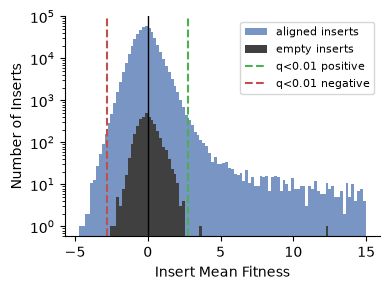

In [10]:
# --- fitness thresholds at the q < 0.05 boundary for the target environment ---
env_aligned = bc_fitness_means[
    (bc_fitness_means["environment"] == ENVIRONMENT) &
    (bc_fitness_means["insert_type"] == "aligned")
]
pos_threshold = env_aligned.loc[
    (env_aligned["fdr_pvalue"] < 0.01) & (env_aligned["z_score"] > 0), "mean_fitness_corrected"
].min()
neg_threshold = env_aligned.loc[
    (env_aligned["fdr_pvalue"] < 0.01) & (env_aligned["z_score"] < 0), "mean_fitness_corrected"
].max()
print(f"q<0.05 positive boundary: {pos_threshold:.3f}")
print(f"q<0.05 negative boundary: {neg_threshold:.3f}")

fig, ax = plt.subplots(figsize=(4, 3))
sns.histplot(
    data=bc_fitness_means[bc_fitness_means["environment"] == ENVIRONMENT],
    x="mean_fitness_corrected",
    hue="insert_type",
    edgecolor="none",
    multiple="stack",
    bins=100,
    palette={"aligned": "#4C72B0", "empty_insert": "black"},
    ax=ax,
)

ax.axvline(x=0,             color="black", lw=1.0)
ax.axvline(x=pos_threshold, color="#4CAF50", linestyle="--", lw=1.5,
           label=f"q<0.01 positive ({pos_threshold:.2f})")
ax.axvline(x=neg_threshold, color="#C0504D", linestyle="--", lw=1.5,
           label=f"q<0.01 negative ({neg_threshold:.2f})")

ax.get_legend().set_title("Insert Type")
ax.legend(
    handles=ax.get_legend().legend_handles + ax.lines[-2:],
    labels=["aligned inserts", "empty inserts"]
         + [f"q<0.01 positive",
            f"q<0.01 negative"],
    fontsize=8,
)
ax.set_yscale("log")
ax.set_ylabel("Number of Inserts")
ax.set_xlabel("Insert Mean Fitness")
#ax.set_title(f"Fitness distribution of aligned and empty inserts\n{ENVIRONMENT}")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

fig.savefig(RESULTS_DIR / "figure2b_insert_fitness_distribution.pdf", bbox_inches="tight")


## Figure 2b — Insert fitness across gene region

Per-barcode `mean_fitness_corrected` plotted as a function of genomic position
for all inserts within `WINDOW_KB` kilobases of `GENE` in `SPECIES`.

In [ ]:
species_dbs = load_local_gff_databases(DATA_DIR / "gff", [SPECIES])


In [12]:
gene_results = pd.read_parquet(GENE_DATA_PATH)

gene_results = gene_results[
    (gene_results["gene_biotype"] != "pseudogene") &
    (gene_results["condition"] == ENVIRONMENT)
]

bsub_lmer = gene_results[
    (gene_results["pioneer_genome"] == SPECIES)
][["gene_id", "lmer_estimate"]].dropna(subset=["lmer_estimate"])

print(f"{len(bsub_lmer):,} B. subtilis {ENVIRONMENT} gene-level LMER estimates loaded")

3,611 B. subtilis LB_4_salt gene-level LMER estimates loaded


In [13]:
pd.set_option("display.max_columns", None)
gene_results[gene_results["gene_id"] == GENE]

,pioneer_genome,species_name,gene_id,locus_tag,gene_bioname,gene_biotype,gene_chrom,gene_strand,gene_start,gene_end,cds_length,protein_id,bayes_estimate,bayes_z_score,bayes_gene_sigma,bayes_q_value,cluster_id,cluster_size,max_r,pip,L,interpretation,condition,lmer_estimate,lmer_standard_error,lmer_shapiro_stat,lmer_shapiro_p,lmer_insert_var,lmer_z_value,lmer_p_value,lmer_q_value,n_inserts,n_sense_inserts,n_antisense_inserts,VIF,gene_call,unk_bucket_0,unk_bucket_1,unk_bucket_2,unk_bucket_3,bayes_island_id,orthogroup,is_single_copy,seed_ortholog,evalue,score,eggNOG_OGs,COG_category,Description,Preferred_name,GOs,EC,KEGG_ko,KEGG_Pathway,KEGG_Module,best_e_coli_k12_match,pident_to_e_coli_k12,PFAMs,PFAM_descriptions,gc_content,CAI_rel_to_Ecoli,EFF_CODON_N,RARE_CODON_N
78675,Bacillus_subtilis_PY79_GCF_023521615.1,Bacillus subtilis,gene-C2H97_RS06675,C2H97_RS06675,murA,protein_coding,NZ_CP026038.1,-,1274086,1275396,1310.0,WP_003227695.1,6.375807,59.592361,0.106834,0.0,2239.0,11.0,0.678754,1.0,1.0,collinear hit (positive),LB_4_salt,12.332778,0.201744,0.877497,0.000008,0.434897,61.130888,0.0,0.0,24.0,10.0,14.0,1.867803,Hit,False,False,False,False,group_548,OG0000515,False,224308.BSU36760,1.079000e-277,854.0,"COG0766@1|root,COG0766@2|Bacteria,1TPAU@1239|F...",M,Cell wall formation. Adds enolpyruvyl to UDP-N...,murA,None,2.5.1.7,ko:K00790,"ko00520,ko00550,ko01100,map00520,map00550,map0...",None,NP_417656.1,50.2,[PF00275],[EPSP synthase (3-phosphoshikimate 1-carboxyvi...,45.61,0.3598,47.46,5.0


In [14]:
# Build one row per barcode carrying positional columns + mean_fitness_corrected.
# The raw inserts table has one row per barcode per replicate; groupby.first()
# collapses replicates so each barcode appears exactly once.
corrected = bc_fitness_means[
    bc_fitness_means["environment"] == ENVIRONMENT
][["bc_sequence", "mean_fitness_corrected"]]

annotated = (
    inserts[
        (inserts["species_full"] == SPECIES) &
        (inserts["environment"] == ENVIRONMENT)
    ]
    .merge(corrected, on="bc_sequence", how="inner")
    .groupby("bc_sequence")
    .first()
    .reset_index()
)

print(f"{len(annotated):,} unique B. subtilis {ENVIRONMENT} barcodes with corrected fitness")

34,402 unique B. subtilis LB_4_salt barcodes with corrected fitness


## Figure 2b (variant) — Insert fitness across gene region (plain)

Same window as Figure 2b: inserts are **black** when they fully span the gene of interest, **gray** otherwise. Gene track uses filled block arrows with no strand-orientation coloring.

Using mean_fitness_corrected


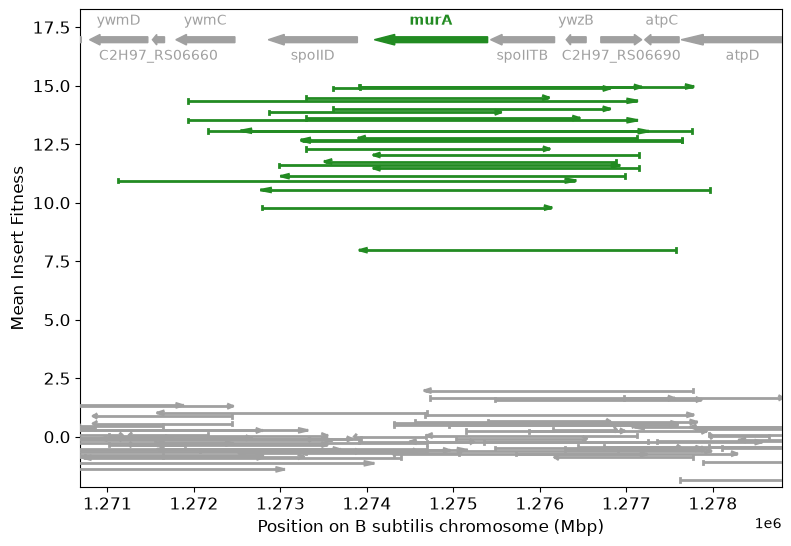

In [15]:
from utils import plot_gene_region_plain

fig, ax = plot_gene_region_plain(
    gene_name=GENE,
    species_name=SPECIES,
    annotated_df=annotated,
    species_dbs_map=species_dbs,
    window_kb=3.4,
    fitness_mode="mean",
    figsize=(8, 6),
)

plt.xlabel("Position on B subtilis chromosome (Mbp)", fontsize=12)
plt.title("", fontsize=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel("Mean Insert Fitness", fontsize=12)

fig.savefig(RESULTS_DIR / "figure2c_variant_gene_region_plain.pdf", bbox_inches="tight")
plt.show()

# Figure 2 D -- insert fitness with estimate overlays

In [16]:
# Resolve plot window from the focal gene
focal     = species_dbs[SPECIES][GENE]
window_bp = 3400
plot_start = max(0, focal.start - window_bp)
plot_end   = focal.end + window_bp

# Build feature_id → genomic centre mapping by querying the DB directly.
# feature.id matches the gene_id format in bsub_lmer ("gene-C2H97_RS00675"),
# whereas _get_genes_in_region returns the Name GFF attribute (gene symbols),
# which does not match.
db = species_dbs[SPECIES]
gene_center = {
    feat.id: (feat.start + feat.end) / 2
    for feat in db.region(seqid=focal.seqid, start=plot_start, end=plot_end, featuretype="gene")
}

overlay = (
    bsub_lmer[bsub_lmer["gene_id"].isin(gene_center)]
    .assign(x=lambda d: d["gene_id"].map(gene_center))
    .sort_values("x")
)
print(f"{len(overlay)} genes with LMER estimates in window")

### Add a gene means

annotated_exploded = annotated[["bc_sequence", "mean_fitness_corrected", "gene_ids_fully_covered"]].explode("gene_ids_fully_covered")
gene_mean = {}
for gene in overlay["gene_id"]:
    gene_mean[gene] = annotated_exploded[annotated_exploded["gene_ids_fully_covered"] == gene]["mean_fitness_corrected"].mean()

overlay["gene_mean"] = overlay["gene_id"].map(gene_mean)
overlay = overlay.merge(gene_results[["gene_id", "gene_bioname"]], on="gene_id", how="left")[1:]

overlay

11 genes with LMER estimates in window


,gene_id,lmer_estimate,x,gene_mean,gene_bioname
1,gene-C2H97_RS06655,-0.163031,1271130.0,-0.284014,ywmD
2,gene-C2H97_RS06660,0.149112,1271590.0,0.269660,C2H97_RS06660
3,gene-C2H97_RS06665,-0.417531,1272132.5,0.159865,ywmC
4,gene-C2H97_RS06670,-0.276357,1273374.5,5.441762,spoIID
5,gene-C2H97_RS06675,12.332778,1274741.0,12.601435,murA
6,gene-C2H97_RS06680,0.527604,1275800.0,7.366009,spoIITB
7,gene-C2H97_RS06685,0.069865,1276420.0,5.819119,ywzB
8,gene-C2H97_RS06690,-0.825086,1276941.5,3.674286,C2H97_RS06690
9,gene-C2H97_RS06695,0.695334,1277411.0,3.166840,atpC
10,gene-C2H97_RS06700,-1.124591,1278344.5,-0.517714,atpD


In [17]:
annotated_exploded_to_plot = annotated_exploded.merge(overlay[["gene_id", "gene_bioname", "x"]], left_on="gene_ids_fully_covered", right_on="gene_id", how="inner").sort_values("x")
annotated_exploded_to_plot.head()

,bc_sequence,mean_fitness_corrected,gene_ids_fully_covered,gene_id,gene_bioname,x
23,AAAAGTACAGAAAACCATCCAGATATTGACATGCTAACATCTG,-0.850917,gene-C2H97_RS06655,gene-C2H97_RS06655,ywmD,1271130.0
53,AATACACAACCTTAGACGACCAGATTTTCCACTGGACTGTGGTG,-0.287305,gene-C2H97_RS06655,gene-C2H97_RS06655,ywmD,1271130.0
33,AACACTCAGGATAGAGATGCAGATCGTGCTCTCTGTACGTTTG,0.268138,gene-C2H97_RS06655,gene-C2H97_RS06655,ywmD,1271130.0
32,AACACAAAACAAATCGTAAGCAGACTGTCACATCGCATGTATTG,-0.816668,gene-C2H97_RS06655,gene-C2H97_RS06655,ywmD,1271130.0
55,AATAGACTACACAAGCCTAGCAGACTTTGTGTACGACTGTTTTG,-0.567971,gene-C2H97_RS06655,gene-C2H97_RS06655,ywmD,1271130.0


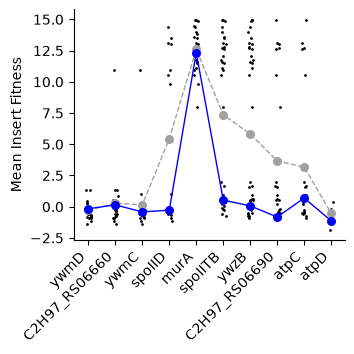

In [18]:
fig, ax = plt.subplots(figsize=(3.5, 3))

sns.stripplot(data=annotated_exploded_to_plot, 
              y="mean_fitness_corrected", x="gene_bioname", 
              color="black",
              s = 2, ax=ax)
plt.ylabel("Mean Insert Fitness")
plt.xlabel("")


ax.plot(overlay["gene_bioname"], overlay["gene_mean"],
        color="#A0A0A0", linewidth=1, zorder=8, linestyle="--")
ax.scatter(overlay["gene_bioname"], overlay["gene_mean"],
           color="#A0A0A0", s=30, zorder=9)

ax.plot(overlay["gene_bioname"], overlay["lmer_estimate"],
        color="blue", linewidth=1, zorder=10)
ax.scatter(overlay["gene_bioname"], overlay["lmer_estimate"],
           color="blue", s=30, zorder=10)

### Remove upper and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=45, ha="right")
plt.show()

fig.savefig(RESULTS_DIR / "figure2d_gene_model.pdf", bbox_inches="tight")


## Figure 2d — Gene analysis pipeline (Sankey)

Genes flow left to right through four decision stages:
1. **Insert coverage** — does the gene have ≥1 aligned barcode?
2. **QC pass** — does the model yield a definitive `Hit` or `Not Hit` call?
3. **Hit call** — is the gene a hit?
4. **Effect direction** — is the LMER estimate positive or negative?

All percentages are relative to total genes in the condition.

In [25]:
import plotly.graph_objects as go

# Reuse gene_results already loaded above; filter to target condition
salt_genes_sk = gene_results[(gene_results["condition"] == ENVIRONMENT) & (gene_results["gene_biotype"] != "pseudogene")].copy()
salt_genes_sk["n_inserts"] = salt_genes_sk["n_inserts"].fillna(0)

# --- Stage counts ---
covered     = salt_genes_sk[salt_genes_sk["n_inserts"] >= 1]
not_covered = salt_genes_sk[salt_genes_sk["n_inserts"] <  1]

n_total       = len(salt_genes_sk)
n_covered     = len(covered)
n_not_covered = len(not_covered)

n_pass_qc = covered["gene_call"].isin(["Hit", "Not Hit"]).sum()
n_fail_qc = (covered["gene_call"] == "Unknown").sum()

n_hit     = (covered["gene_call"] == "Hit").sum()
n_not_hit = (covered["gene_call"] == "Not Hit").sum()

hits_sk   = covered[covered["gene_call"] == "Hit"]
n_pos_hit = (hits_sk["lmer_estimate"] > 0).sum()
n_neg_hit = (hits_sk["lmer_estimate"] < 0).sum()


def node_label(name, n):
    return f"{name}<br>{n:,} ({n / n_total:.1%})"


labels = [
    node_label("All genes",   n_total),
    node_label("Covered >= 1x",     n_covered),
    node_label("Not covered", n_not_covered),
    node_label("Pass LM QC",     n_pass_qc),
    node_label("Fail LM QC",     n_fail_qc),
    node_label("Significant",         n_hit),
    node_label("Not significant",     n_not_hit),
    node_label("Positive Effect",    n_pos_hit),
    node_label("Negative Effect",    n_neg_hit),
]

node_x = [0.01, 0.25, 0.25, 0.50, 0.50, 0.75, 0.75, 0.99, 0.99]
node_y = [0.40, 0.25, 0.82, 0.15, 0.72, 0.08, 0.48, -0.15, 0.25]

node_colors = [
    "#888888",  # All genes
    "#5B9BD5",  # Covered
    "#D0D0D0",  # Not covered
    "#4CAF50",  # Pass QC
    "#E87722",  # Fail QC
    "#C0504D",  # Hit
    "#404040",  # Not Hit
    "#1F4E79",  # Positive
    "#A52A2A",  # Negative
]

link_colors = [
    "rgba(91,155,213,0.35)",   # All → Covered
    "rgba(200,200,200,0.35)",  # All → Not covered
    "rgba(76,175,80,0.35)",    # Covered → Pass QC
    "rgba(232,119,34,0.35)",   # Covered → Fail QC
    "rgba(192,80,77,0.35)",    # Pass QC → Hit
    "rgba(64,64,64,0.30)",     # Pass QC → Not Hit
    "rgba(31,78,121,0.35)",    # Hit → Positive
    "rgba(165,42,42,0.35)",    # Hit → Negative
]

fig_sk = go.Figure(go.Sankey(
    arrangement="fixed",
    node=dict(
        pad=20,
        thickness=25,
        line=dict(color="white", width=0.5),
        label=labels,
        color=node_colors,
        x=node_x,
        y=node_y,
    ),
    link=dict(
        source=[0, 0, 1, 1, 3, 3, 5, 5],
        target=[1, 2, 3, 4, 5, 6, 7, 8],
        value=[n_covered, n_not_covered,
               n_pass_qc, n_fail_qc,
               n_hit, n_not_hit,
               n_pos_hit, n_neg_hit],
        color=link_colors,
    ),
))

fig_sk.update_layout(
    font_size=18,
    height=520,
    width=1000,
)
fig_sk.write_image(str(RESULTS_DIR / "figure2_sankey_gene_pipeline.pdf"))
fig_sk.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed